# Stock Market Analysis

Analyzing historical stock market data to identify trends and patterns in stock prices over time. Visualizing stock performance against moving averages and trading volume.

**Dataset:** Apple Inc. (AAPL) Historical Stock Prices
**Tools:** Pandas, Matplotlib, Seaborn, NumPy

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("AAPL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-08-16,51.070000,51.790001,50.959999,51.625000,49.954624,110481600
1,2019-08-19,52.654999,53.182499,52.507500,52.587502,50.885971,97654400
2,2019-08-20,52.720001,53.337502,52.580002,52.590000,50.888390,107537200
3,2019-08-21,53.247501,53.412498,52.900002,53.160000,51.439960,86141600
4,2019-08-22,53.297501,53.610001,52.687500,53.115002,51.396420,89014800


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   str    
 1   Open       1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Close      1258 non-null   float64
 5   Adj Close  1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 68.9 KB


## 3. Data Cleaning

In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,1258,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,2022-02-13 16:24:25.182830,141.038025,142.633732,139.563692,141.171045,139.424360,9.488958e+07
min,2019-08-16 00:00:00,51.025002,51.430000,50.250000,50.660000,49.020844,2.404830e+07
25%,2020-11-12 06:00:00,120.080000,121.497503,118.662503,120.099996,117.742945,6.044670e+07
50%,2022-02-12 12:00:00,147.245002,149.050003,145.809998,147.474998,145.651512,8.134545e+07
75%,2023-05-15 18:00:00,172.327503,173.994996,170.919995,172.690002,171.252552,1.119275e+08
max,2024-08-15 00:00:00,236.479996,237.229996,233.089996,234.820007,234.548523,4.265100e+08
std,NaN,41.806681,42.122371,41.508559,41.817774,42.219063,5.199224e+07


In [6]:
df['Daily Return'] = df['Adj Close'].pct_change() * 100
df['Daily Range'] = df['High'] - df['Low']
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily Return,Daily Range
0,2019-08-16,51.070000,51.790001,50.959999,51.625000,49.954624,110481600,NaN,0.830002
1,2019-08-19,52.654999,53.182499,52.507500,52.587502,50.885971,97654400,1.864386,0.674999
2,2019-08-20,52.720001,53.337502,52.580002,52.590000,50.888390,107537200,0.004754,0.757500
3,2019-08-21,53.247501,53.412498,52.900002,53.160000,51.439960,86141600,1.083882,0.512496
4,2019-08-22,53.297501,53.610001,52.687500,53.115002,51.396420,89014800,-0.084642,0.922501


## 4. Closing Price Over Time

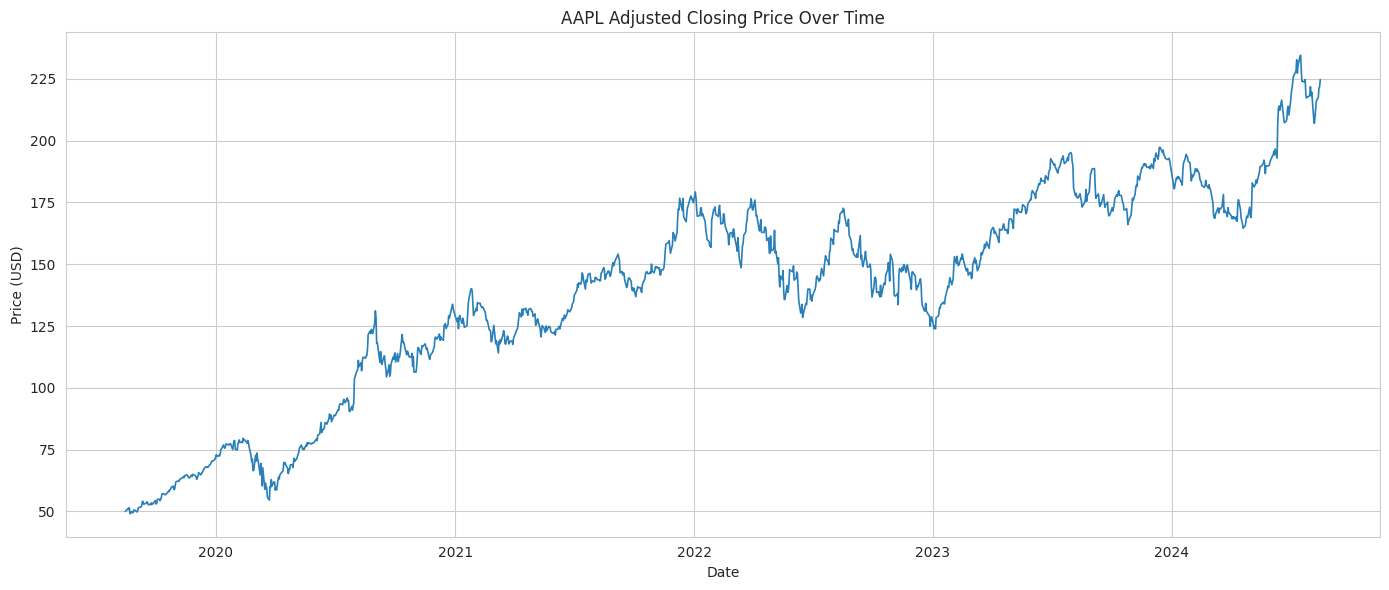

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Adj Close'], color='#2980b9', linewidth=1.2)
plt.title('AAPL Adjusted Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

## 5. Moving Averages

In [8]:
df['MA20'] = df['Adj Close'].rolling(window=20).mean()
df['MA50'] = df['Adj Close'].rolling(window=50).mean()
df['MA200'] = df['Adj Close'].rolling(window=200).mean()
df[['Date', 'Adj Close', 'MA20', 'MA50', 'MA200']].tail()

,Date,Adj Close,MA20,MA50,MA200
1253,2024-08-09,215.990005,219.883489,214.507709,189.937574
1254,2024-08-12,217.529999,219.053539,215.036933,190.162439
1255,2024-08-13,221.270004,218.389613,215.621778,190.417644
1256,2024-08-14,221.720001,218.044844,216.180065,190.696043
1257,2024-08-15,224.720001,218.084804,216.791959,190.982825


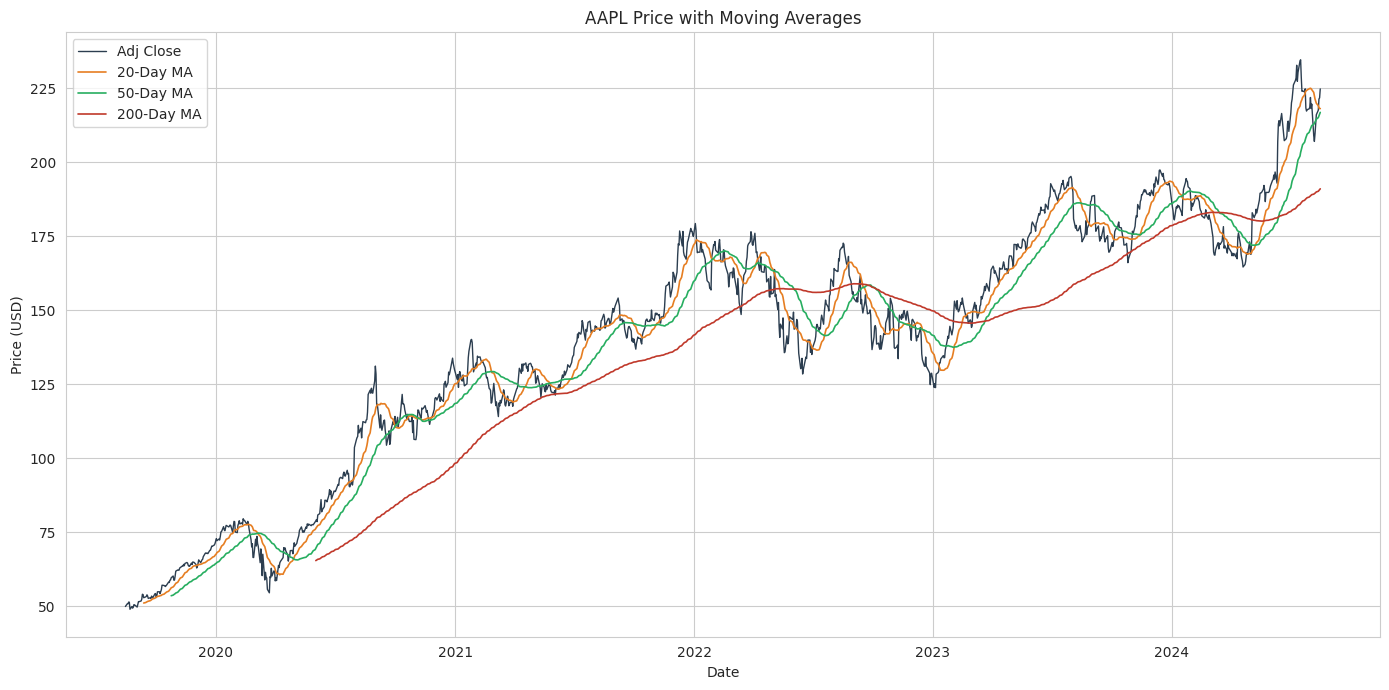

In [9]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Adj Close'], label='Adj Close', color='#2c3e50', linewidth=1)
plt.plot(df['Date'], df['MA20'], label='20-Day MA', color='#e67e22', linewidth=1.2)
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='#27ae60', linewidth=1.2)
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='#c0392b', linewidth=1.2)
plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Trading Volume Over Time

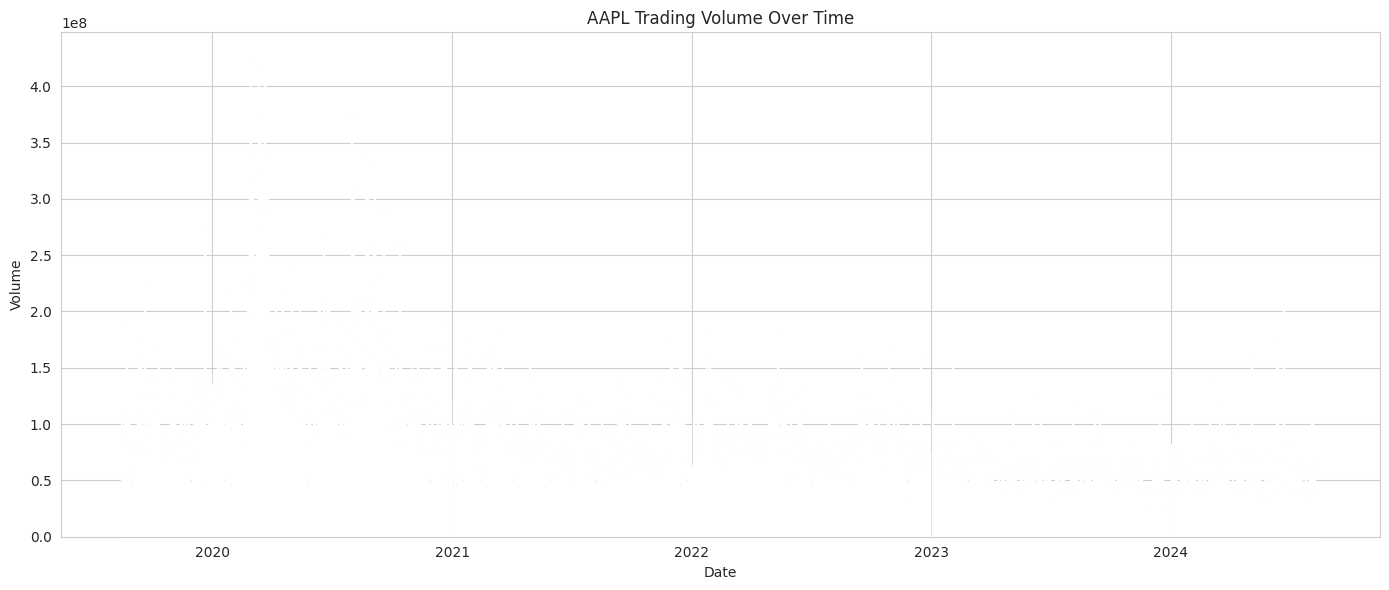

In [10]:
plt.figure(figsize=(14, 6))
plt.bar(df['Date'], df['Volume'], color='#7f8c8d', width=1.5)
plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

## 7. Price vs Volume

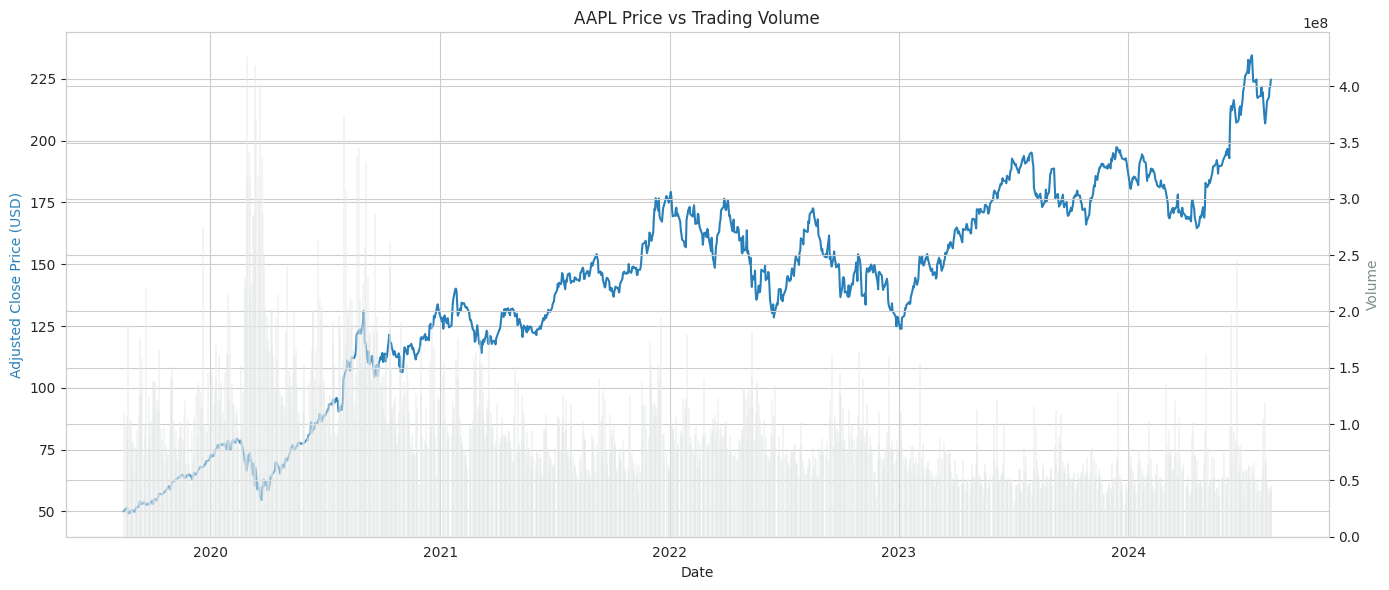

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['Date'], df['Adj Close'], color='#2980b9')
ax1.set_xlabel('Date')
ax1.set_ylabel('Adjusted Close Price (USD)', color='#2980b9')

ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Volume'], color='#95a5a6', alpha=0.3, width=1.5)
ax2.set_ylabel('Volume', color='#7f8c8d')

plt.title('AAPL Price vs Trading Volume')
plt.tight_layout()
plt.show()

## 8. Daily Returns Distribution

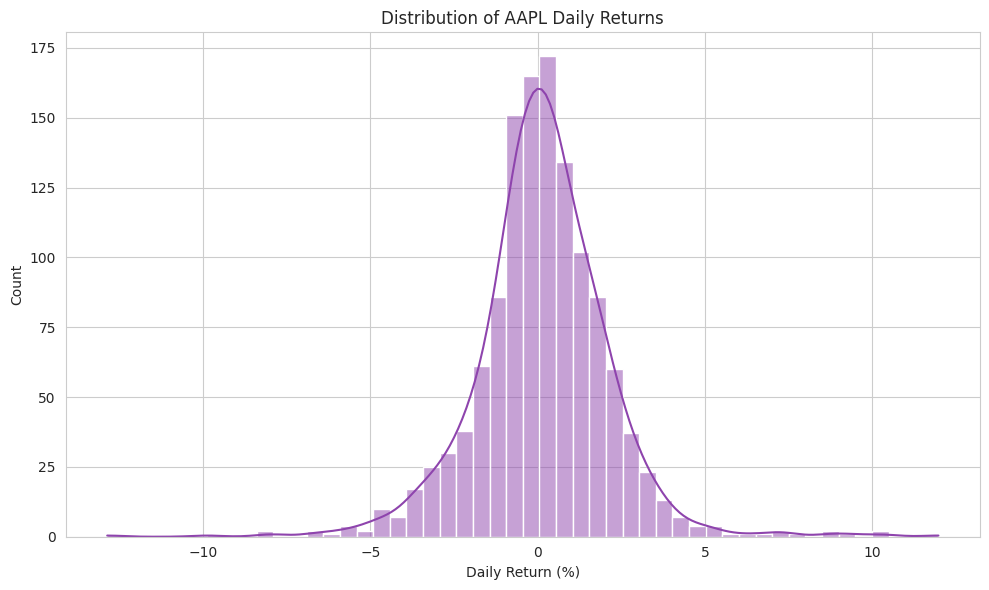

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily Return'].dropna(), bins=50, kde=True, color='#8e44ad')
plt.title('Distribution of AAPL Daily Returns')
plt.xlabel('Daily Return (%)')
plt.tight_layout()
plt.show()

## 9. Daily Returns Over Time

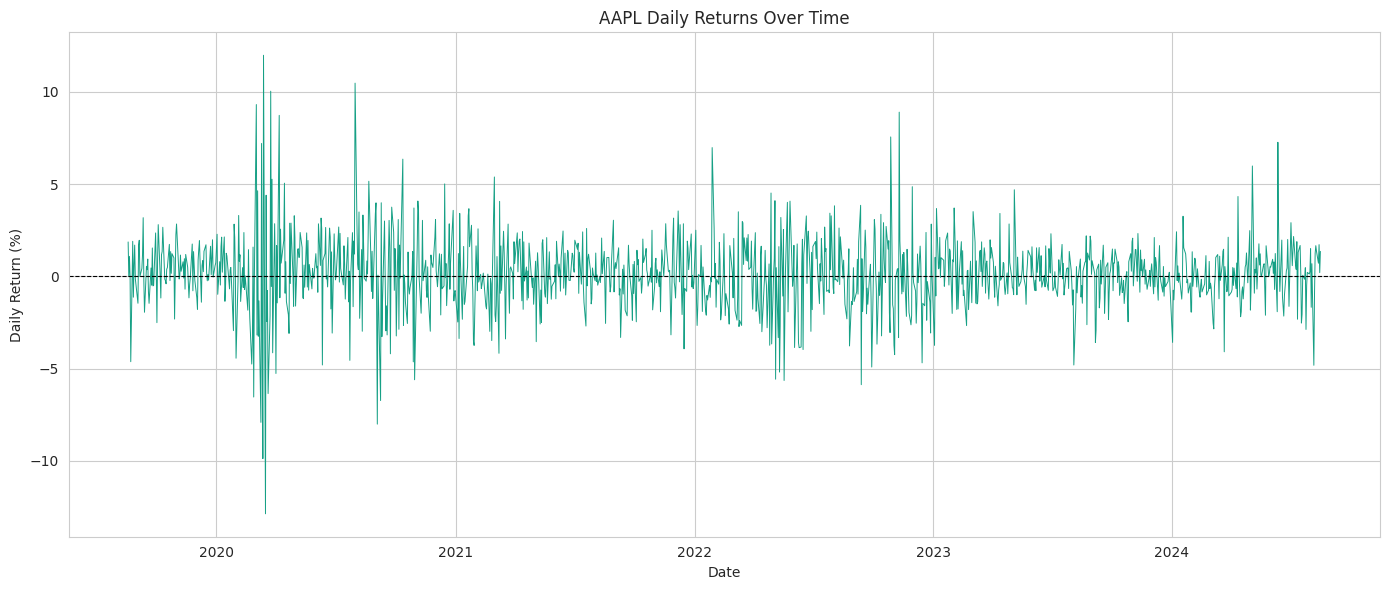

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Daily Return'], color='#16a085', linewidth=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('AAPL Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

## 10. Rolling Volatility

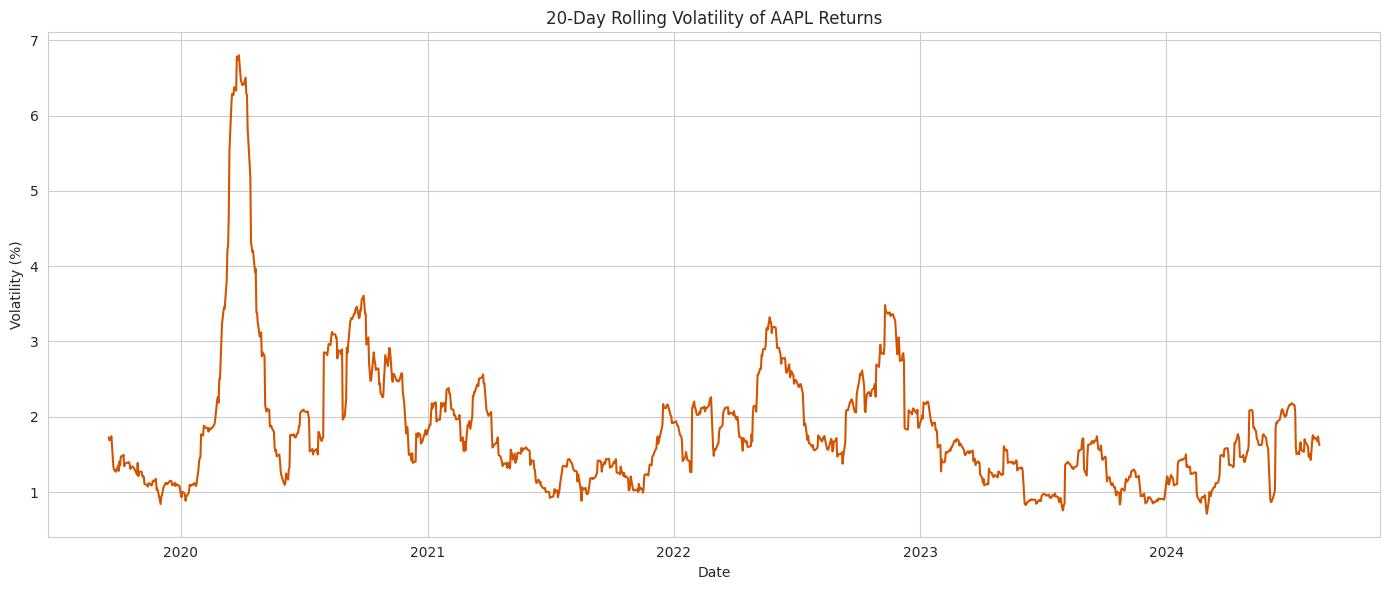

In [14]:
df['Volatility_20'] = df['Daily Return'].rolling(window=20).std()

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Volatility_20'], color='#d35400')
plt.title('20-Day Rolling Volatility of AAPL Returns')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.tight_layout()
plt.show()

## 11. Yearly Performance Summary

In [15]:
df['Year'] = df['Date'].dt.year
yearly_summary = df.groupby('Year').agg(
    Start_Price=('Adj Close', 'first'),
    End_Price=('Adj Close', 'last'),
    Avg_Volume=('Volume', 'mean'),
    Max_Price=('Adj Close', 'max'),
    Min_Price=('Adj Close', 'min')
)
yearly_summary['Yearly Return %'] = (yearly_summary['End_Price'] / yearly_summary['Start_Price'] - 1) * 100
yearly_summary

,Start_Price,End_Price,Avg_Volume,Max_Price,Min_Price,Yearly Return %
Year,,,,,,
2019,49.954624,71.250435,1.042491e+08,71.250435,49.020844,42.630310
2020,72.876114,129.894333,1.575646e+08,133.810089,54.569729,78.239928
2021,126.683456,174.900375,9.052463e+07,177.618866,114.078598,38.060944
2022,179.273575,128.719330,8.791038e+07,179.273575,124.865593,-28.199496
2023,123.904625,191.802185,5.921703e+07,197.361084,123.855087,54.798245
2024,184.938217,224.720001,6.319494e+07,234.548523,164.585999,21.510851


/tmp/ipykernel_552/116939742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_summary.index, y=yearly_summary['Yearly Return %'], palette='Blues_d')


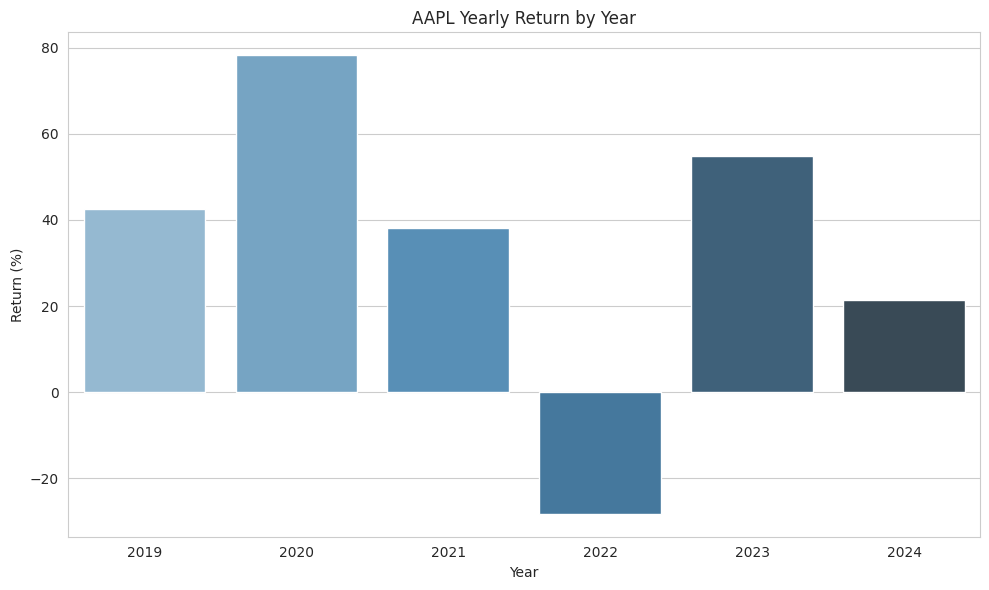

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_summary.index, y=yearly_summary['Yearly Return %'], palette='Blues_d')
plt.title('AAPL Yearly Return by Year')
plt.xlabel('Year')
plt.ylabel('Return (%)')
plt.tight_layout()
plt.show()

## 12. Candlestick-Style OHLC Snapshot (Last 60 Days)

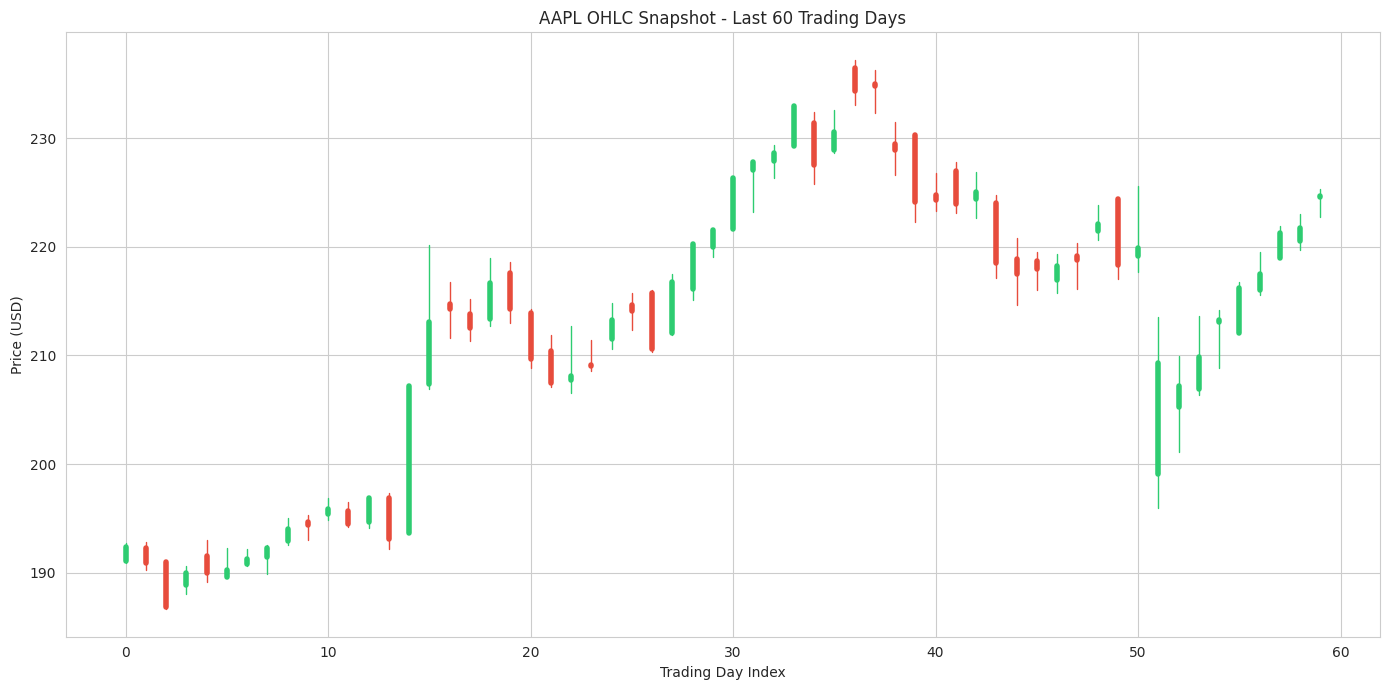

In [17]:
recent = df.tail(60).reset_index(drop=True)

plt.figure(figsize=(14, 7))
for i in range(len(recent)):
    color = '#2ecc71' if recent.loc[i, 'Close'] >= recent.loc[i, 'Open'] else '#e74c3c'
    plt.plot([i, i], [recent.loc[i, 'Low'], recent.loc[i, 'High']], color=color, linewidth=1)
    plt.plot([i, i], [recent.loc[i, 'Open'], recent.loc[i, 'Close']], color=color, linewidth=4)

plt.title('AAPL OHLC Snapshot - Last 60 Trading Days')
plt.xlabel('Trading Day Index')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

## 13. Correlation Between Price, Volume, and Range

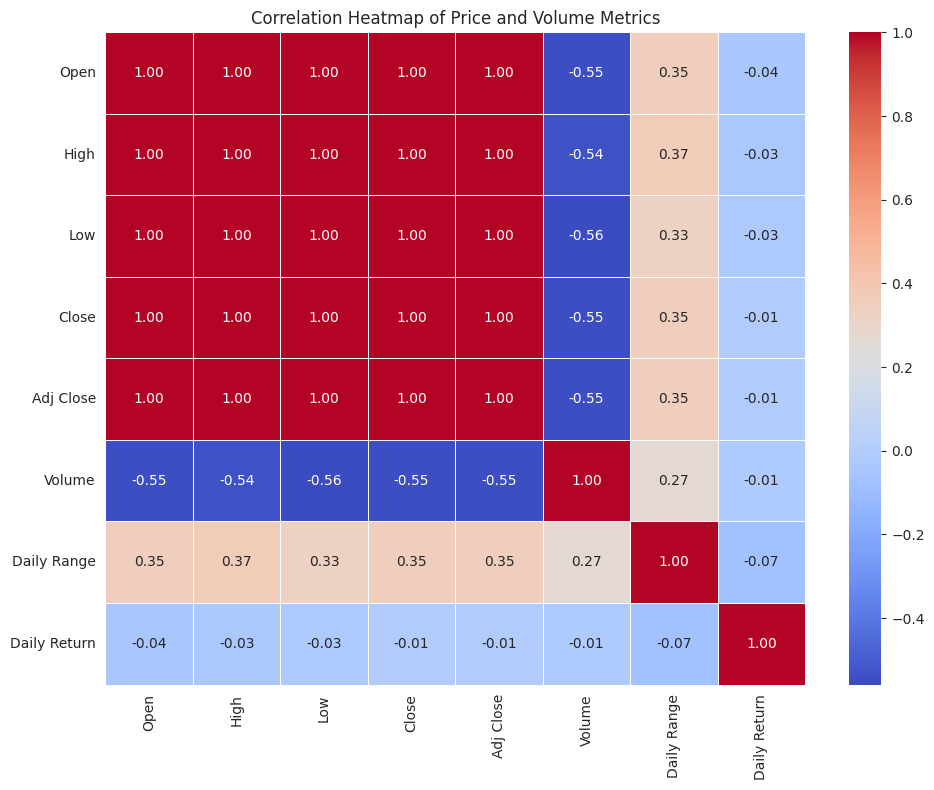

In [18]:
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily Range', 'Daily Return']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Price and Volume Metrics')
plt.tight_layout()
plt.show()

## 14. Cumulative Returns

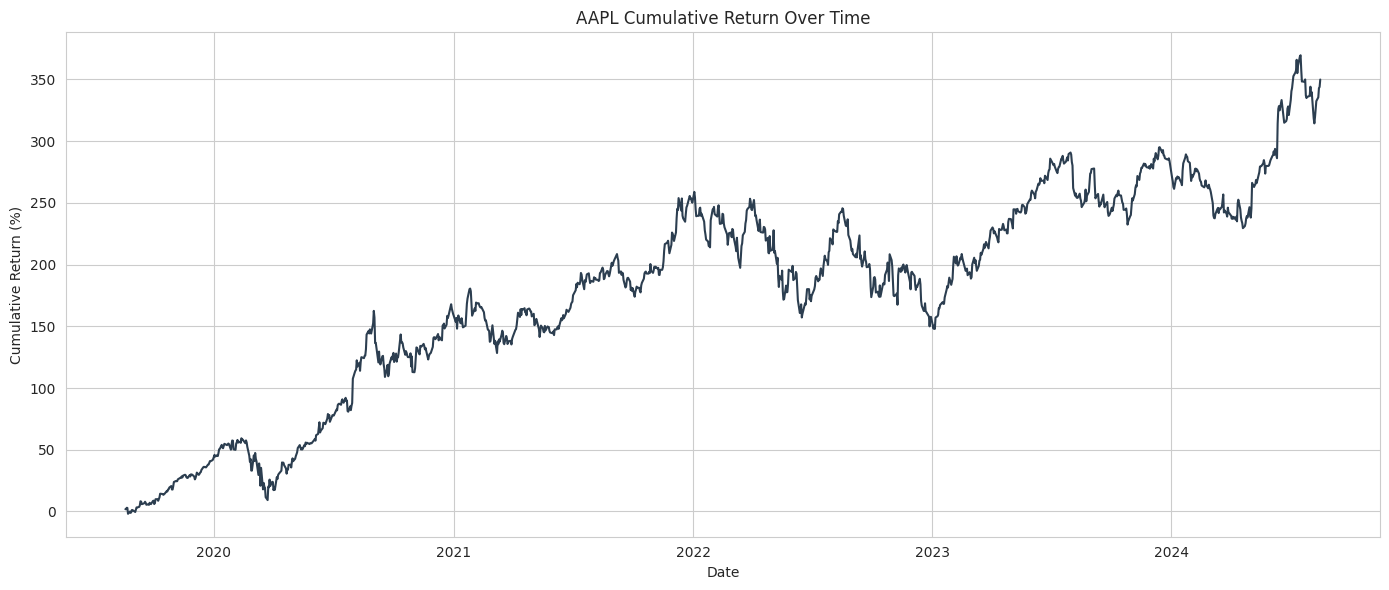

In [19]:
df['Cumulative Return'] = (1 + df['Daily Return'] / 100).cumprod() - 1

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative Return'] * 100, color='#2c3e50')
plt.title('AAPL Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.tight_layout()
plt.show()